#  ERK vs. AKT Propagation Comparison
Hypothesis: ERK and AKT biosensors report on different signaling pathways that may
exhibit distinct spatiotemporal propagation patterns.

#### 1. Imports and paths 

In [37]:
from pathlib import Path
import sys
import subprocess
import json

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path("..").resolve()

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_PATH = PROJECT_ROOT / "data" / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = PROJECT_ROOT / "data" / "01-readme-experiment-description_2022-04-05.csv"

OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs"
FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_ROOT.mkdir(exist_ok=True)
FINAL_OUTPUT_DIR.mkdir(exist_ok=True)

print("DATA exists:", DATA_PATH.exists())
print("META exists:", META_PATH.exists())
print("SCRIPT exists:", (SCRIPTS_DIR / "spatiotemporal_signal_propagation.py").exists())



DATA exists: True
META exists: True
SCRIPT exists: True


#### 2. Metadata loading and block selection

In [ ]:
# Select same experiment-site blocks for both biosensors
meta = pd.read_csv(META_PATH, encoding="utf-8-sig")
meta = meta.rename(columns={"Site": "Image_Metadata_Site"})

selected_mutations = ["WT", "AKT1_E17K", "PTEN_del"]

# Get all valid experiment-site pairs that actually exist in the tracking data.
tracks_blocks = (
    pd.read_csv(
        DATA_PATH,
        usecols=["Exp_ID", "Image_Metadata_Site"]
    )
    .drop_duplicates()
    .rename(columns={
        "Exp_ID": "exp_id",
        "Image_Metadata_Site": "site_id"
    })
)

# Select all metadata sites for the chosen mutations.
selected_sites = (
    meta[meta["Mutation"].isin(selected_mutations)]
    [["Mutation", "Image_Metadata_Site"]]
    .drop_duplicates()
    .rename(columns={
        "Mutation": "mutation",
        "Image_Metadata_Site": "site_id"
    })
)

# Match selected mutation sites with real exp_id/site_id pairs from the tracking data.
selected_blocks = (
    selected_sites
    .merge(tracks_blocks, on="site_id", how="inner")
    [["mutation", "exp_id", "site_id"]]
    .sort_values(["mutation", "exp_id", "site_id"])
    .reset_index(drop=True)
)

selected_blocks["exp_id"] = selected_blocks["exp_id"].astype(int)
selected_blocks["site_id"] = selected_blocks["site_id"].astype(int)

print(f"Selected valid experiment-site blocks: {len(selected_blocks)}")
print(selected_blocks.to_string(index=False))

Selected valid experiment-site blocks: 72
 mutation  exp_id  site_id
AKT1_E17K       1        5
AKT1_E17K       1        6
AKT1_E17K       1        7
AKT1_E17K       1        8
AKT1_E17K       2        7
AKT1_E17K       2        8
AKT1_E17K       3        5
AKT1_E17K       3        6
AKT1_E17K       3        7
AKT1_E17K       3        8
AKT1_E17K       4        5
AKT1_E17K       4        6
AKT1_E17K       4        7
AKT1_E17K       4        8
AKT1_E17K       5        6
AKT1_E17K       5        7
AKT1_E17K       5        8
AKT1_E17K       6        5
AKT1_E17K       6        6
AKT1_E17K       6        7
AKT1_E17K       6        8
 PTEN_del       1       17
 PTEN_del       1       18
 PTEN_del       1       19
 PTEN_del       1       20
 PTEN_del       2       17
 PTEN_del       2       18
 PTEN_del       2       19
 PTEN_del       2       20
 PTEN_del       3       17
 PTEN_del       3       18
 PTEN_del       3       19
 PTEN_del       3       20
 PTEN_del       4       17
 PTEN_del    

The first table shows available mutations and imaging sites present in the metadata.  
The second table contains the experiment-site blocks selected for downstream analysis.

#### 3. Running propagation analysis for both biosensors
The spatiotemporal propagation pipeline is executed separately for `ERKKTR_ratio` and `FoxO3A_ratio` using identical analysis parameters and the same experiment-site blocks.

In [39]:
signals = {
    "ERKKTR_ratio": "ERKKTR_ratio",
    "FoxO3A_ratio": "FoxO3A_ratio"
}

SPATIAL_RADIUS = 60
FUTURE_WINDOW = 3
JUMP_QUANTILE = 0.9

rows = []

for block in selected_blocks.itertuples(index=False):
    for signal_label, signal_col in signals.items():
        
        outdir = (OUTPUT_ROOT /f"TaskB_{block.mutation}_exp{block.exp_id}_site{block.site_id}_{signal_label}")
        
        cmd = [
            sys.executable,
            str(SCRIPTS_DIR / "spatiotemporal_signal_propagation.py"),
            "--data-path", str(DATA_PATH),
            "--meta-path", str(META_PATH),
            "--exp-id", str(block.exp_id),
            "--site-id", str(block.site_id),
            "--signal-col", signal_col,
            "--spatial-radius", str(SPATIAL_RADIUS),
            "--future-window-frames", str(FUTURE_WINDOW),
            "--jump-quantile", str(JUMP_QUANTILE),
            "--output-dir", str(outdir),
        ]
        
        print(f"Running {block.mutation} | {signal_label}")
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            print(result.stderr)
            raise RuntimeError(f"Script failed for {block.mutation} | {signal_label}")
        
        summary_path = (
            outdir /
            f"exp_{block.exp_id}_site_{block.site_id}_{signal_col}" /
            "summary.json"
        )
        
        with open(summary_path) as f:
            s = json.load(f)
        
        rows.append({
            "mutation": block.mutation,
            "exp_id": block.exp_id,
            "site_id": block.site_id,
            "biosensor": signal_label,
            "signal_col": signal_col,
            "jump_threshold_theta": s["jump_threshold"],
            "p_exposed": s["future_jump_rate_if_neighbor_jumps_now"],
            "p_unexposed": s["future_jump_rate_if_no_neighbor_jumps_now"],
            "risk_difference": s["risk_difference"],
            "RR": s["relative_risk"],
            "n_nodes": s["n_nodes"],
            "n_spatial_edges": s["n_spatial_edges"],
        })

b1_df = pd.DataFrame(rows)
display(b1_df)

# Calculate mean propagation statistics across blocks.
summary_df = (
    b1_df
    .groupby(["mutation", "biosensor"], as_index=False)
    .agg(
        mean_RR=("RR", "mean"),
        std_RR=("RR", "std"),
        mean_theta=("jump_threshold_theta", "mean"),
        n_blocks=("RR", "count")
    )
)

display(summary_df)

Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running AK

,mutation,exp_id,site_id,biosensor,signal_col,jump_threshold_theta,p_exposed,p_unexposed,risk_difference,RR,n_nodes,n_spatial_edges
0,AKT1_E17K,1,5,ERKKTR_ratio,ERKKTR_ratio,0.022628,0.155272,0.096390,0.058883,1.610885,448311,3863383
1,AKT1_E17K,1,5,FoxO3A_ratio,FoxO3A_ratio,0.046550,0.152510,0.118690,0.033820,1.284947,448311,3863383
2,AKT1_E17K,1,6,ERKKTR_ratio,ERKKTR_ratio,0.021569,0.166842,0.083748,0.083094,1.992198,440567,3882605
3,AKT1_E17K,1,6,FoxO3A_ratio,FoxO3A_ratio,0.044560,0.158121,0.112229,0.045892,1.408911,440567,3882605
4,AKT1_E17K,1,7,ERKKTR_ratio,ERKKTR_ratio,0.023369,0.171658,0.073368,0.098290,2.339684,382261,2803597
...,...,...,...,...,...,...,...,...,...,...,...,...
139,WT,6,2,FoxO3A_ratio,FoxO3A_ratio,0.030258,0.155876,0.117014,0.038862,1.332118,292522,1612541
140,WT,6,3,ERKKTR_ratio,ERKKTR_ratio,0.049485,0.138148,0.074931,0.063217,1.843681,284116,1515115
141,WT,6,3,FoxO3A_ratio,FoxO3A_ratio,0.032181,0.158696,0.113671,0.045025,1.396096,284116,1515115
142,WT,6,4,ERKKTR_ratio,ERKKTR_ratio,0.047200,0.132513,0.078721,0.053792,1.683328,318206,1917620


,mutation,biosensor,mean_RR,std_RR,mean_theta,n_blocks
0,AKT1_E17K,ERKKTR_ratio,1.581421,0.329635,0.020493,21
1,AKT1_E17K,FoxO3A_ratio,1.272374,0.080330,0.042547,21
2,PTEN_del,ERKKTR_ratio,1.556633,0.112361,0.071923,27
3,PTEN_del,FoxO3A_ratio,1.401192,0.127419,0.049894,27
4,WT,ERKKTR_ratio,1.742349,0.084226,0.048879,24
5,WT,FoxO3A_ratio,1.373404,0.093429,0.034558,24


#### 4. Save comparison table

In [40]:
b1_df.to_csv(FINAL_OUTPUT_DIR / "B1_ERK_vs_AKT_comparison_table.csv", index=False)

print("Saved:")
print(FINAL_OUTPUT_DIR / "B1_ERK_vs_AKT_comparison_table.csv")

Saved:
/home/m/biologiaSystemów/projekt2/outputs/B1_ERK_vs_AKT_comparison_table.csv


#### 5. Visualizing RR differences between biosensors

biosensor,ERKKTR_ratio,FoxO3A_ratio
mutation,,
AKT1_E17K,1.581421,1.272374
PTEN_del,1.556633,1.401192
WT,1.742349,1.373404


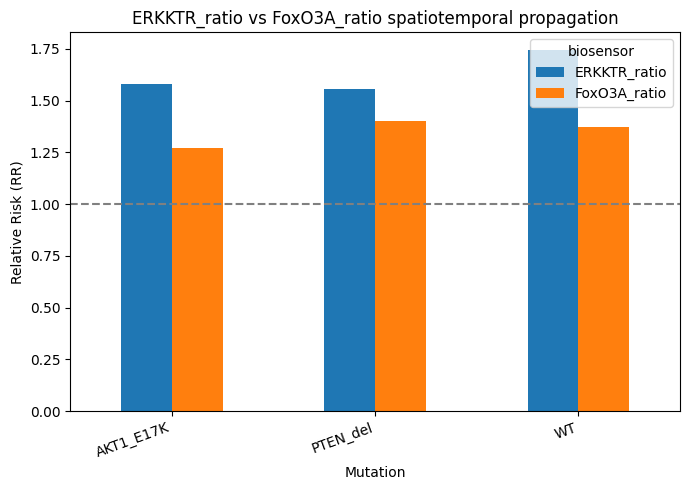

In [41]:
plot_df = summary_df.pivot(
    index="mutation",
    columns="biosensor",
    values="mean_RR"
)

display(plot_df)

fig, ax = plt.subplots(figsize=(7, 5))

plot_df.plot(
    kind="bar",
    ax=ax
)

ax.axhline(1, linestyle="--", color="gray")

ax.set_ylabel("Relative Risk (RR)")
ax.set_xlabel("Mutation")
ax.set_title("ERKKTR_ratio vs FoxO3A_ratio spatiotemporal propagation")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "B1_ERK_vs_FoxO3A_RR_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 6. Visualizing jump thresholds

biosensor,ERKKTR_ratio,FoxO3A_ratio
mutation,,
AKT1_E17K,0.020493,0.042547
PTEN_del,0.071923,0.049894
WT,0.048879,0.034558


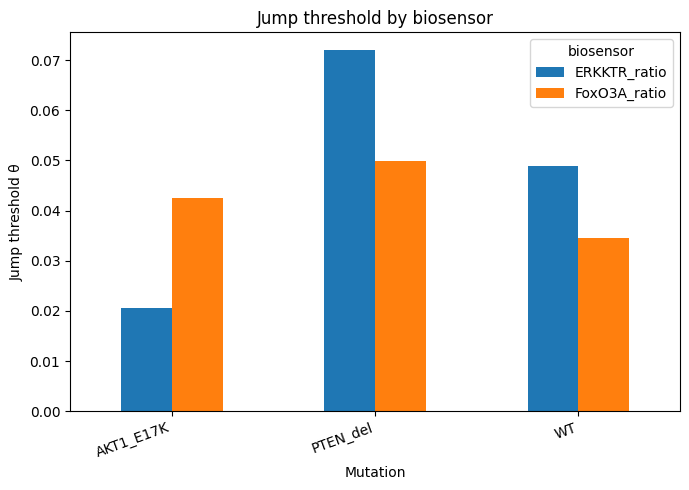

In [44]:
theta_df = summary_df.pivot(
    index="mutation",
    columns="biosensor",
    values="mean_theta"
)

fig, ax = plt.subplots(figsize=(7, 5))

theta_df.plot(
    kind="bar",
    ax=ax
)

display(theta_df)

ax.set_ylabel("Jump threshold θ")
ax.set_xlabel("Mutation")
ax.set_title("Jump threshold by biosensor")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "B1_ERK_vs_FoxO3A_theta_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 7. Overall interpretation

In [47]:
erk_mean = b1_df[b1_df["biosensor"] == "ERKKTR_ratio"]["RR"].mean()
akt_mean = b1_df[b1_df["biosensor"] == "FoxO3A_ratio"]["RR"].mean()

print(f"Mean RR for ERKKTR_ratio: {erk_mean:.3f}")
print(f"Mean RR for FoxO3A_ratio: {akt_mean:.3f}")

if erk_mean > akt_mean:
    print("ERKKTR_ratio shows stronger average spatiotemporal propagation than FoxO3A_ratio.")
elif akt_mean > erk_mean:
    print("FoxO3A_ratio shows stronger average spatiotemporal propagation than ERKKTR_ratio.")
else:
    print("Both biosensors show similar average propagation strength.")

Mean RR for ERKKTR_ratio: 1.626
Mean RR for FoxO3A_ratio: 1.354
ERKKTR_ratio shows stronger average spatiotemporal propagation than FoxO3A_ratio.
